# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?
5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities?
6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/labll_data/pierce_county_house_sales.csv')
display(df.head())

,sale_date,sale_price,house_square_feet,attic_finished_square_feet,basement_square_feet,attached_garage_square_feet,detached_garage_square_feet,fireplaces,hvac_description,exterior,interior,stories,roof_cover,year_built,bedrooms,bathrooms,waterfront_type,view_quality,utility_sewer
0,2020-01-02,380000,2157,0,0,528,0,0,Warm and Cool Air Zone,Frame Siding,Drywall,2,Composition Shingle,1993,3,3,NaN,NaN,SEWER/SEPTIC INSTALLED
1,2020-01-02,383000,2238,0,0,396,0,0,Forced Air,Frame Siding,Drywall,2,Composition Shingle,2017,4,3,NaN,NaN,SEWER/SEPTIC INSTALLED
2,2020-01-01,419900,1452,0,0,0,0,1,Forced Air,Frame Siding,Drywall,1,Built Up Rock,1965,3,2,NaN,NaN,SEWER/SEPTIC INSTALLED
3,2020-01-02,251660,832,0,0,0,0,0,Forced Air,Frame Vinyl,Drywall,1,Composition Shingle,1919,2,1,NaN,NaN,SEWER/SEPTIC INSTALLED
4,2020-01-02,500000,1780,0,384,484,0,1,Forced Air,Frame Siding,Drywall,1,Composition Shingle,1955,3,2,NaN,NaN,SEWER/SEPTIC INSTALLED


Shape: (16814, 19)


,sale_date,sale_price,house_square_feet,attic_finished_square_feet,basement_square_feet,attached_garage_square_feet,detached_garage_square_feet,fireplaces,hvac_description,exterior,interior,stories,roof_cover,year_built,bedrooms,bathrooms,waterfront_type,view_quality,utility_sewer
0,2020-01-02,380000,2157,0,0,528,0,0,Warm and Cool Air Zone,Frame Siding,Drywall,2,Composition Shingle,1993,3,3,NaN,NaN,SEWER/SEPTIC INSTALLED
1,2020-01-02,383000,2238,0,0,396,0,0,Forced Air,Frame Siding,Drywall,2,Composition Shingle,2017,4,3,NaN,NaN,SEWER/SEPTIC INSTALLED
2,2020-01-01,419900,1452,0,0,0,0,1,Forced Air,Frame Siding,Drywall,1,Built Up Rock,1965,3,2,NaN,NaN,SEWER/SEPTIC INSTALLED
3,2020-01-02,251660,832,0,0,0,0,0,Forced Air,Frame Vinyl,Drywall,1,Composition Shingle,1919,2,1,NaN,NaN,SEWER/SEPTIC INSTALLED
4,2020-01-02,500000,1780,0,384,484,0,1,Forced Air,Frame Siding,Drywall,1,Composition Shingle,1955,3,2,NaN,NaN,SEWER/SEPTIC INSTALLED


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16814 entries, 0 to 16813
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   sale_date                    16814 non-null  object
 1   sale_price                   16814 non-null  int64 
 2   house_square_feet            16814 non-null  int64 
 3   attic_finished_square_feet   16814 non-null  int64 
 4   basement_square_feet         16814 non-null  int64 
 5   attached_garage_square_feet  16814 non-null  int64 
 6   detached_garage_square_feet  16814 non-null  int64 
 7   fireplaces                   16814 non-null  int64 
 8   hvac_description             16807 non-null  object
 9   exterior                     16813 non-null  object
 10  interior                     16807 non-null  object
 11  stories                      16814 non-null  int64 
 12  roof_cover                   16806 non-null  object
 13  year_built                   16

None

,dtype,missing,missing_pct,n_unique
waterfront_type,object,16261,96.71,4
view_quality,object,15895,94.53,8
roof_cover,object,8,0.05,6
hvac_description,object,7,0.04,9
interior,object,7,0.04,2
exterior,object,1,0.01,16
sale_date,object,0,0.00,362
house_square_feet,int64,0,0.00,2947
sale_price,int64,0,0.00,3606
detached_garage_square_feet,int64,0,0.00,236


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sale_date,16814,362,2020-07-28,109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sale_price,16814.0,NaN,NaN,NaN,461233.191507,236083.342854,2000.0,348000.0,416500.0,523806.5,6130000.0
house_square_feet,16814.0,NaN,NaN,NaN,1879.941953,760.419008,1.0,1320.0,1774.0,2352.0,9510.0
attic_finished_square_feet,16814.0,NaN,NaN,NaN,24.945878,102.066417,0.0,0.0,0.0,0.0,1212.0
basement_square_feet,16814.0,NaN,NaN,NaN,167.852861,429.065832,0.0,0.0,0.0,0.0,4000.0
attached_garage_square_feet,16814.0,NaN,NaN,NaN,364.425122,286.454018,0.0,0.0,420.0,528.0,2816.0
detached_garage_square_feet,16814.0,NaN,NaN,NaN,38.298501,164.691471,0.0,0.0,0.0,0.0,3664.0
fireplaces,16814.0,NaN,NaN,NaN,0.889021,0.596731,0.0,1.0,1.0,1.0,5.0
hvac_description,16807,9,Forced Air,10382,NaN,NaN,NaN,NaN,NaN,NaN,NaN
exterior,16813,16,Frame Siding,14577,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Duplicates before: 46
Shape after dropping duplicates: (16768, 19)


,0
sale_date,0
sale_price,0
house_square_feet,0
attic_finished_square_feet,0
basement_square_feet,0
attached_garage_square_feet,0
detached_garage_square_feet,0
fireplaces,0
hvac_description,0
exterior,0


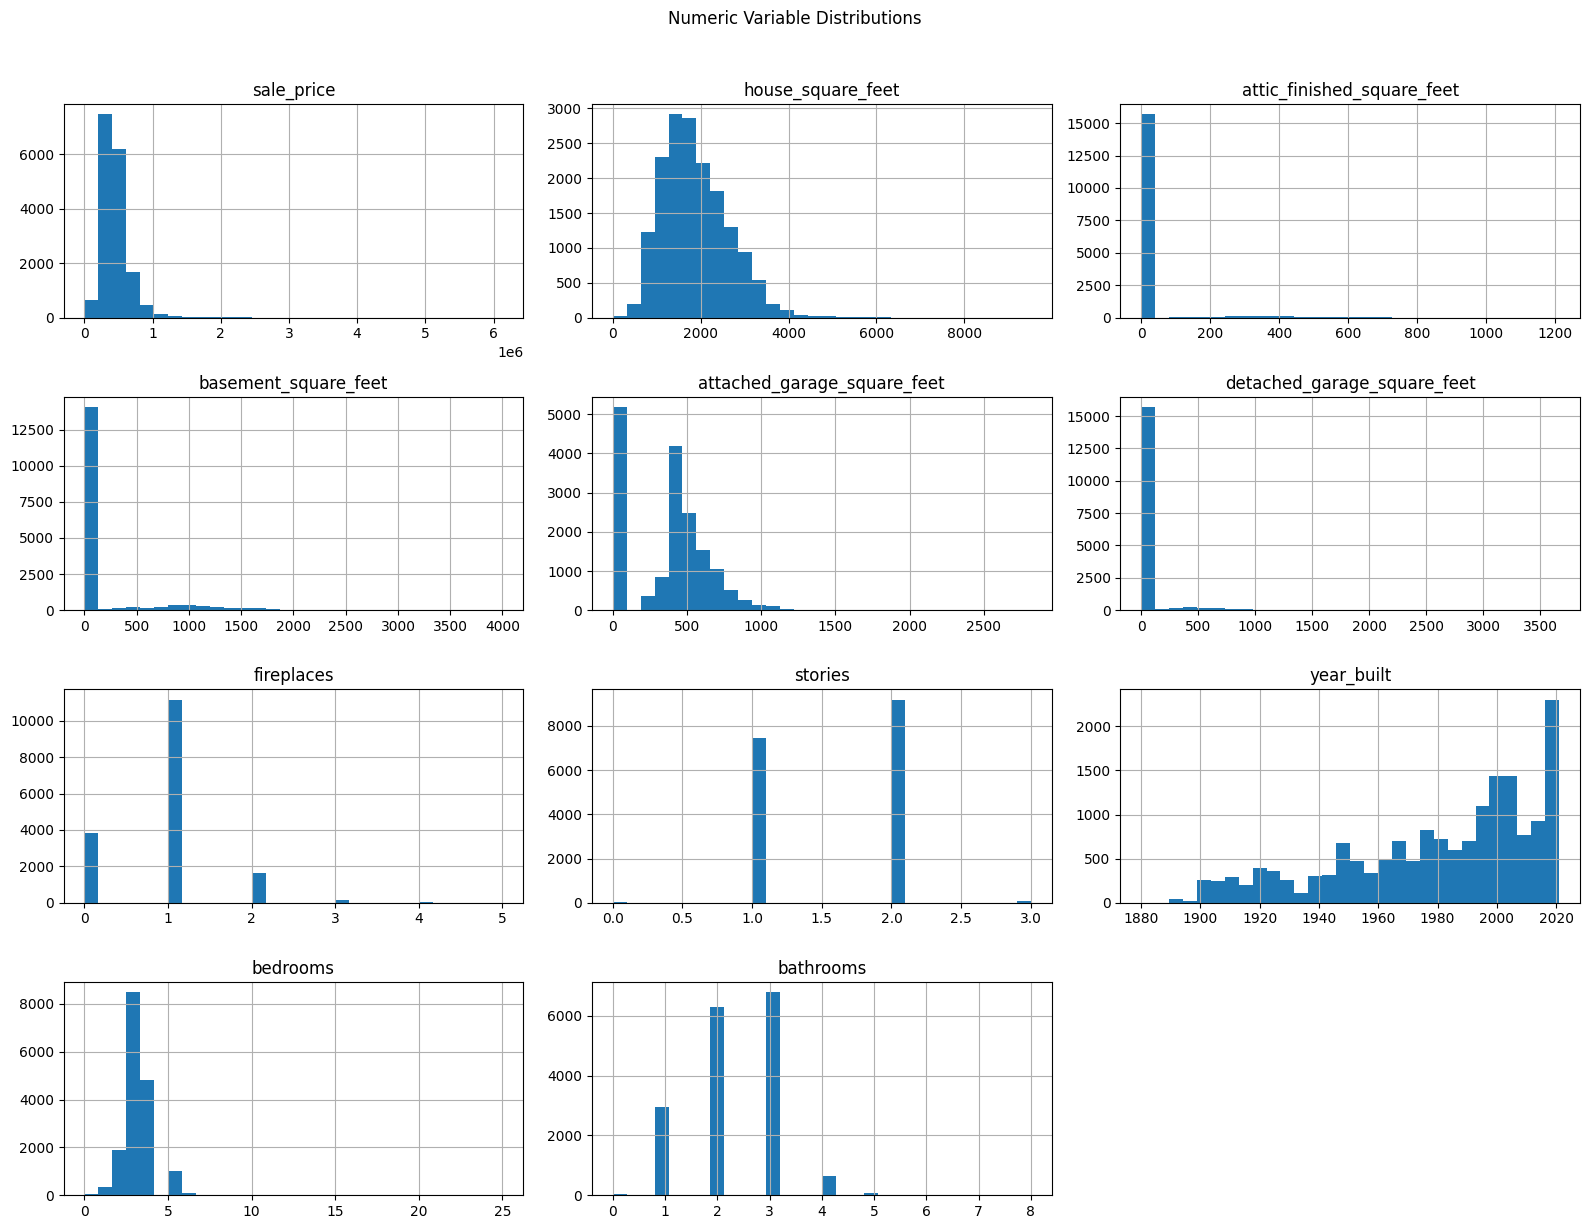

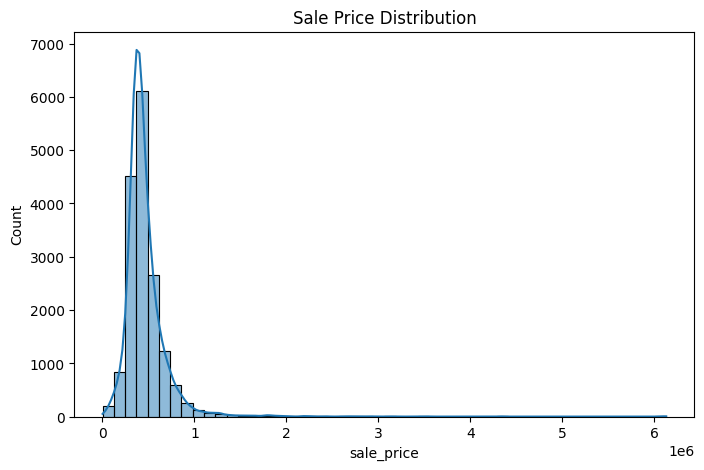

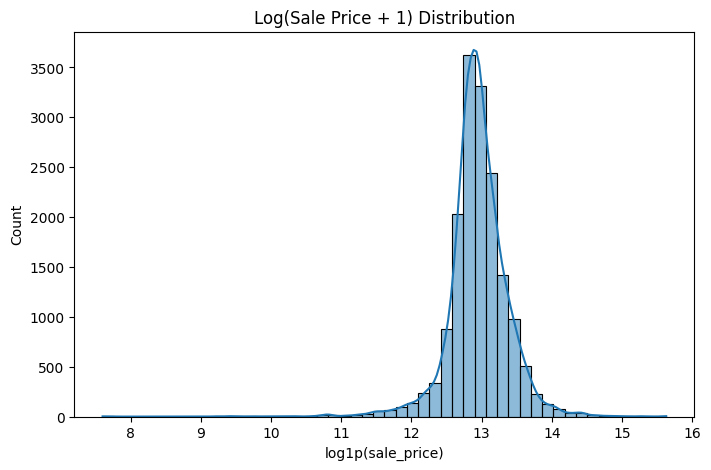

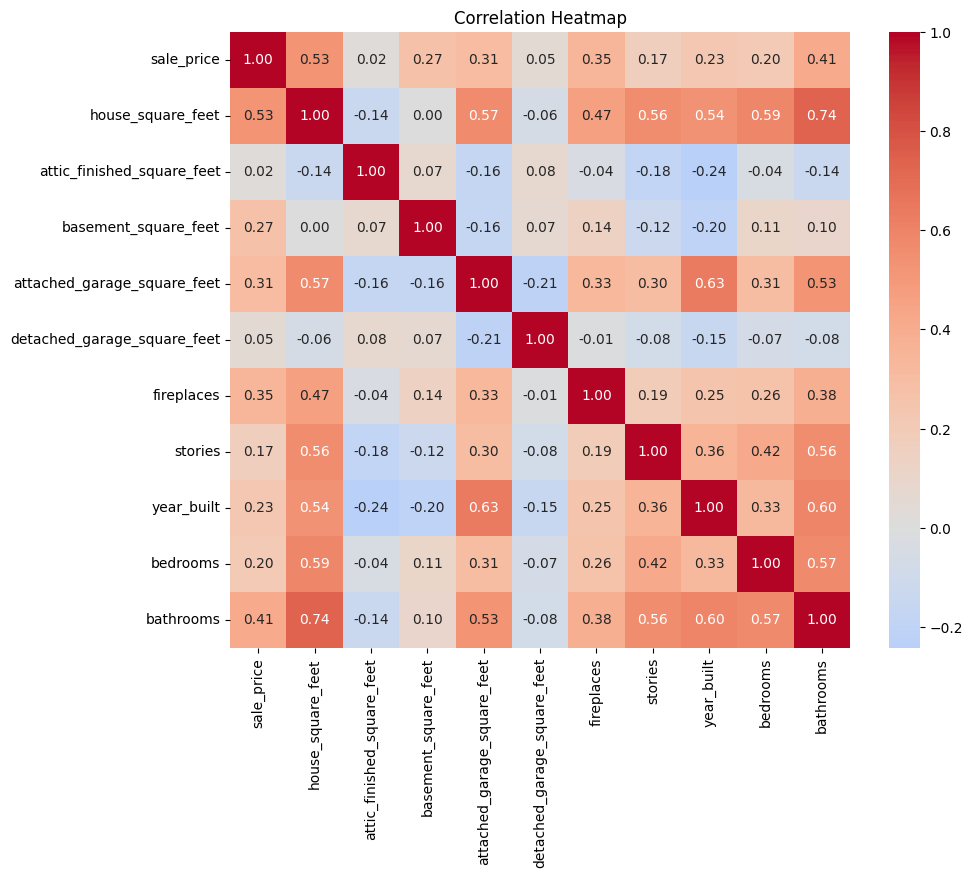

,sale_price
sale_price,1.000000
house_square_feet,0.525828
bathrooms,0.409170
fireplaces,0.347678
attached_garage_square_feet,0.310396
basement_square_feet,0.270301
year_built,0.228875
bedrooms,0.204819
stories,0.166498
detached_garage_square_feet,0.051994


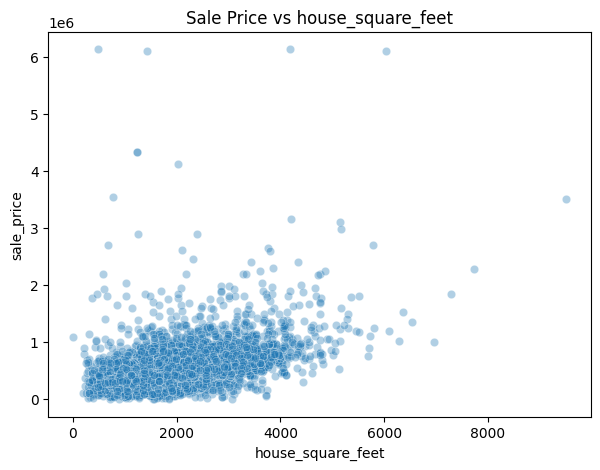

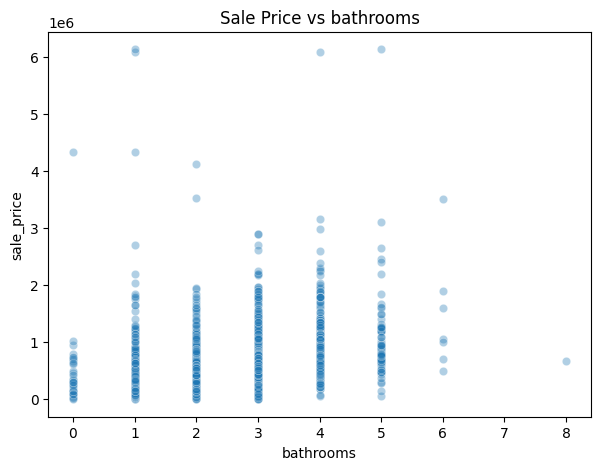

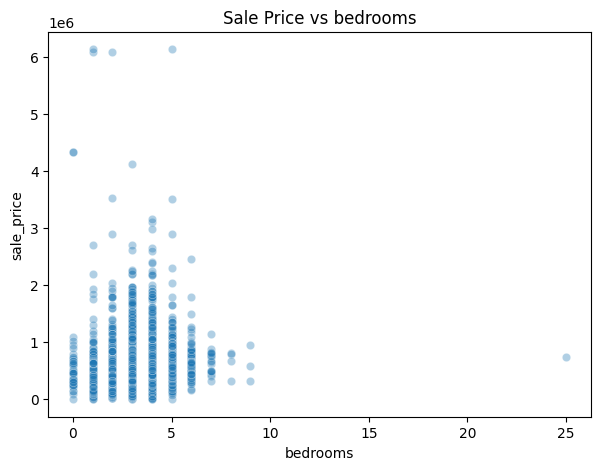

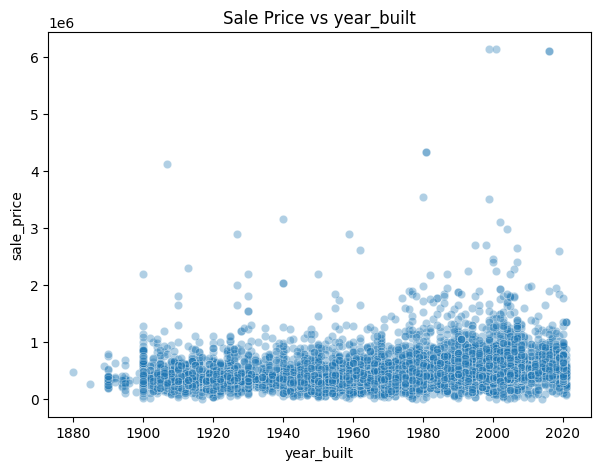

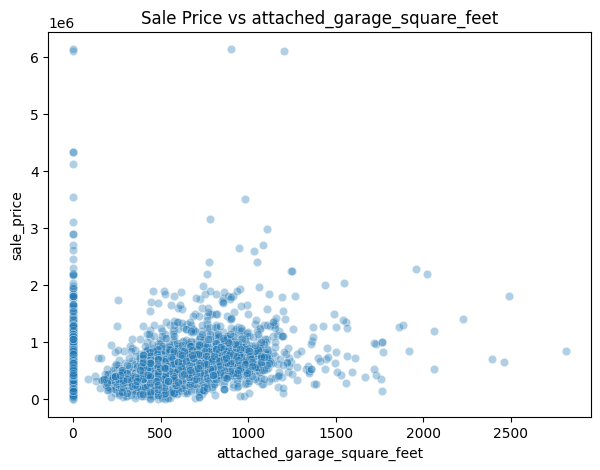

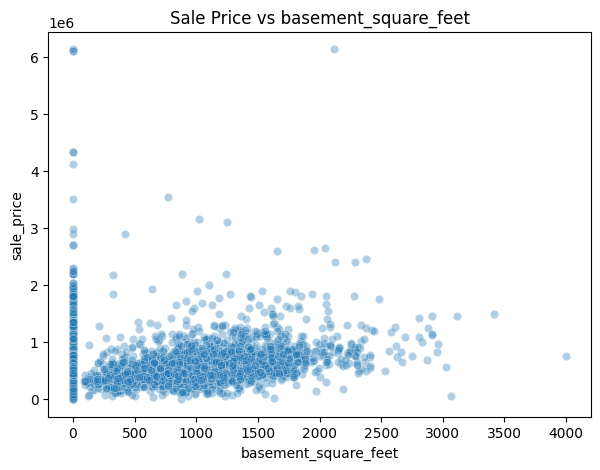

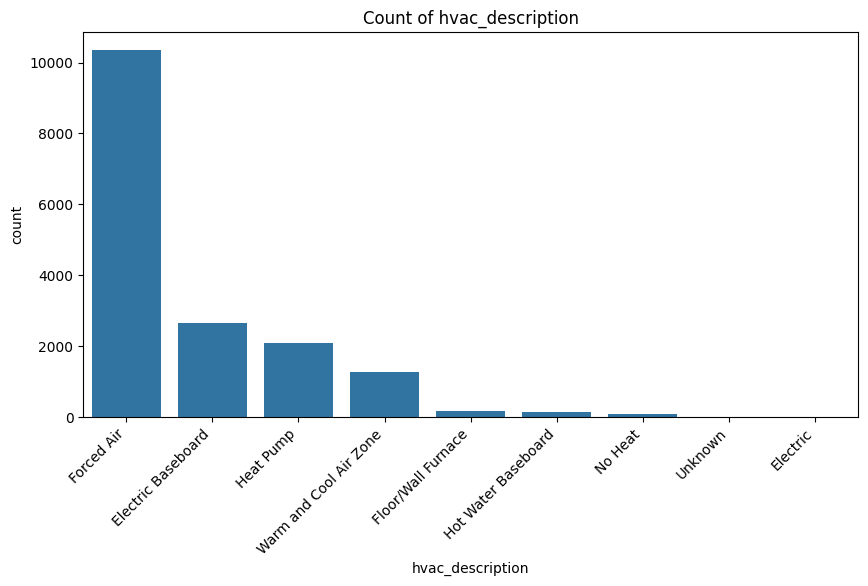

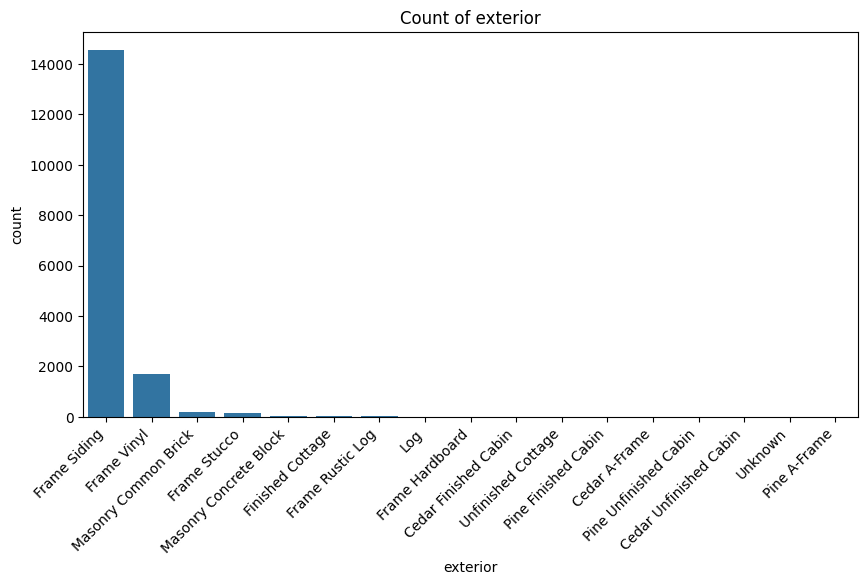

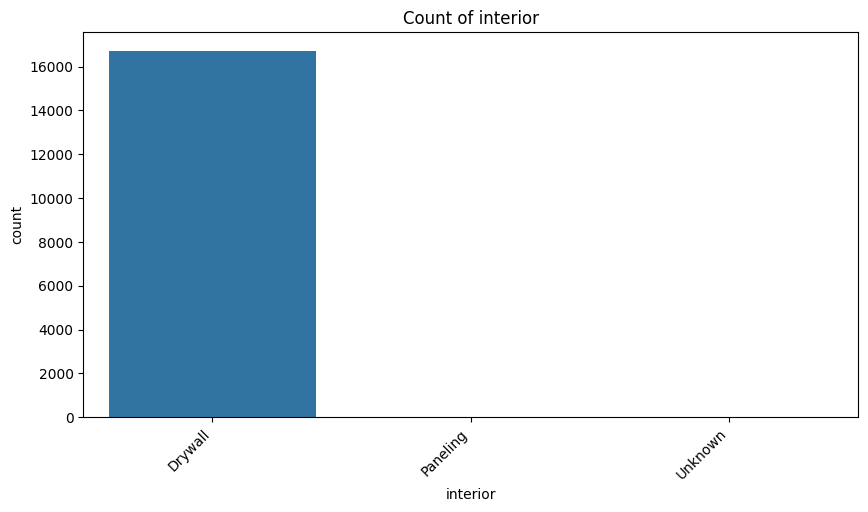

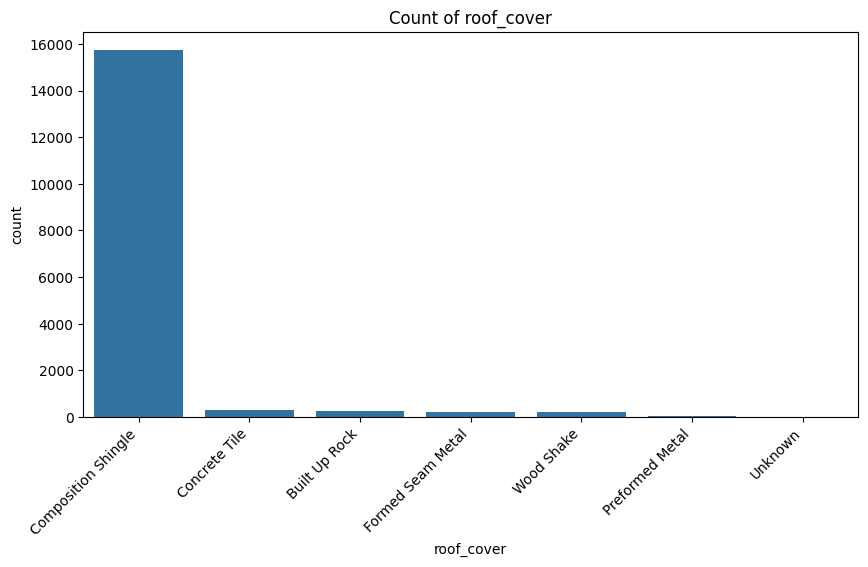

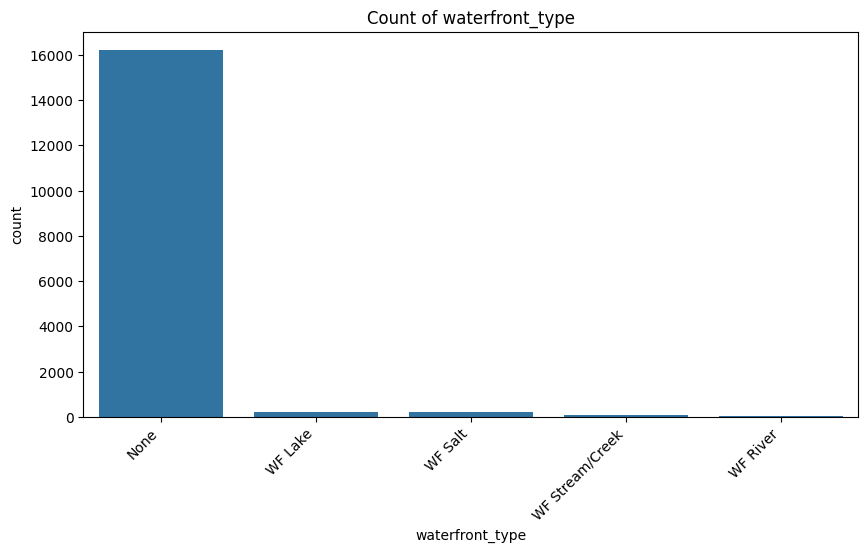

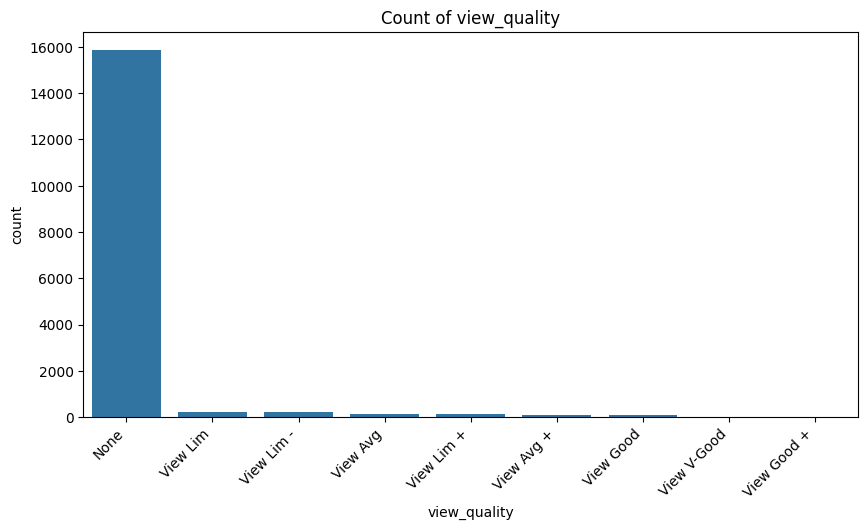

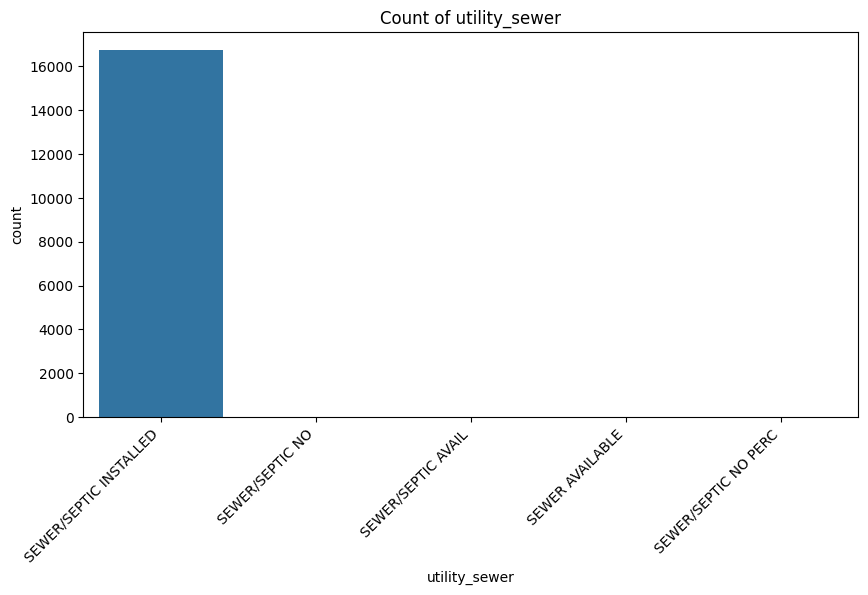

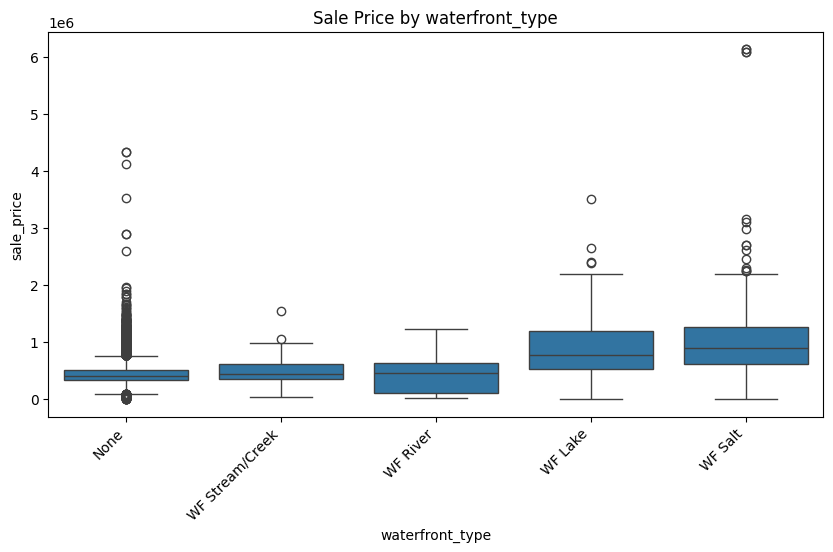

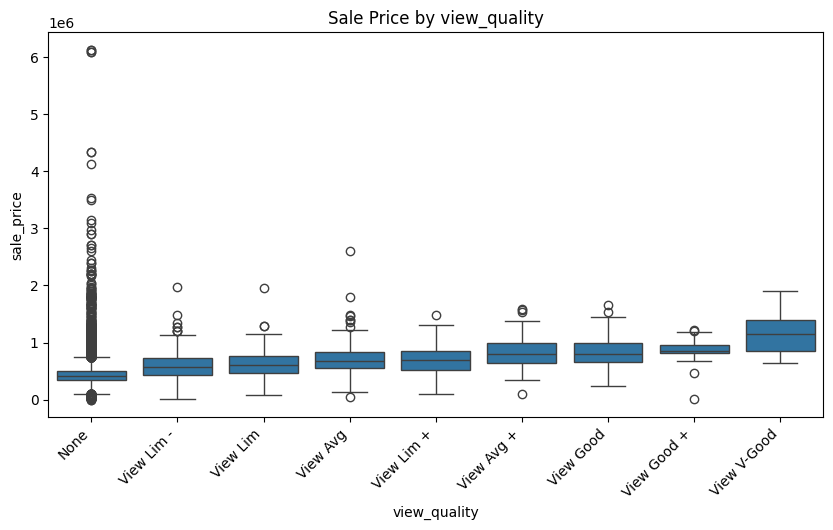

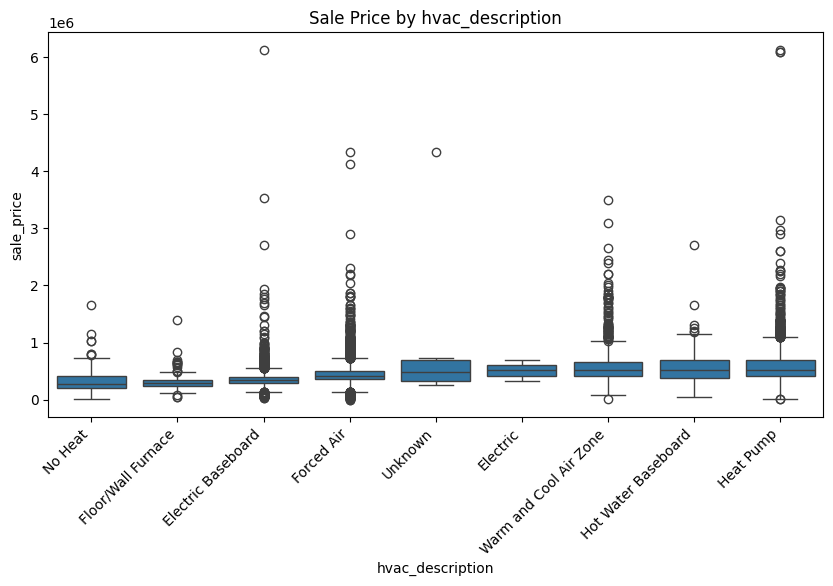

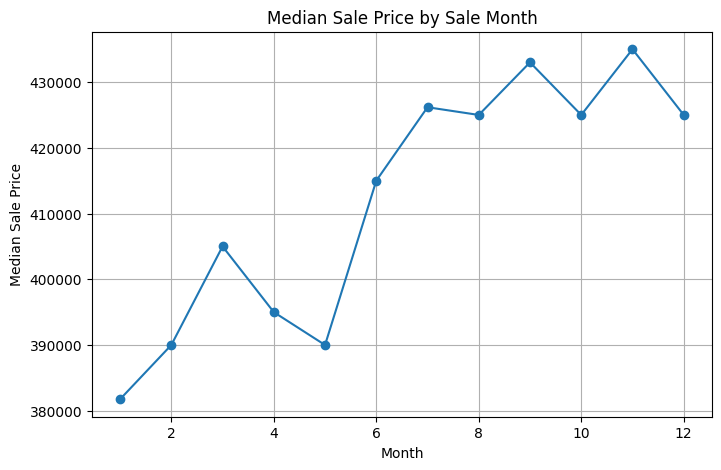

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Shape:", df.shape)
display(df.head())
display(df.info())

summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique()
}).sort_values("missing_pct", ascending=False)

display(summary)
display(df.describe(include="all").T)

df_clean = df.copy()

df_clean["sale_date"] = pd.to_datetime(df_clean["sale_date"])

print("Duplicates before:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()
print("Shape after dropping duplicates:", df_clean.shape)

df_clean["hvac_description"] = df_clean["hvac_description"].replace({
    "Floor Wall Furnace": "Floor/Wall Furnace"
})

df_clean["waterfront_type"] = df_clean["waterfront_type"].fillna("None")
df_clean["view_quality"] = df_clean["view_quality"].fillna("None")

for col in ["hvac_description", "exterior", "interior", "roof_cover"]:
    df_clean[col] = df_clean[col].fillna("Unknown")

df_clean["sale_year"] = df_clean["sale_date"].dt.year
df_clean["sale_month"] = df_clean["sale_date"].dt.month

display(df_clean.isna().sum().sort_values(ascending=False))

numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove("sale_year")
numeric_cols.remove("sale_month")

df_clean[numeric_cols].hist(figsize=(16, 12), bins=30)
plt.suptitle("Numeric Variable Distributions", y=1.02)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df_clean["sale_price"], bins=50, kde=True)
plt.title("Sale Price Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df_clean["sale_price"]), bins=50, kde=True)
plt.title("Log(Sale Price + 1) Distribution")
plt.xlabel("log1p(sale_price)")
plt.show()

plt.figure(figsize=(10,8))
corr = df_clean[numeric_cols].corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

price_corr = df_clean[numeric_cols].corr(numeric_only=True)["sale_price"].sort_values(ascending=False)
display(price_corr)

key_num_vars = [
    "house_square_feet",
    "bathrooms",
    "bedrooms",
    "year_built",
    "attached_garage_square_feet",
    "basement_square_feet"
]

for col in key_num_vars:
    plt.figure(figsize=(7,5))
    sns.scatterplot(data=df_clean, x=col, y="sale_price", alpha=0.35)
    plt.title(f"Sale Price vs {col}")
    plt.show()

cat_cols = [
    "hvac_description",
    "exterior",
    "interior",
    "roof_cover",
    "waterfront_type",
    "view_quality",
    "utility_sewer"
]

for col in cat_cols:
    plt.figure(figsize=(10,5))
    order = df_clean[col].value_counts().index
    sns.countplot(data=df_clean, x=col, order=order)
    plt.title(f"Count of {col}")
    plt.xticks(rotation=45, ha="right")
    plt.show()

important_cat = ["waterfront_type", "view_quality", "hvac_description"]

for col in important_cat:
    plt.figure(figsize=(10,5))
    order = df_clean.groupby(col)["sale_price"].median().sort_values().index
    sns.boxplot(data=df_clean, x=col, y="sale_price", order=order)
    plt.title(f"Sale Price by {col}")
    plt.xticks(rotation=45, ha="right")
    plt.show()

monthly_price = df_clean.groupby("sale_month")["sale_price"].median()

plt.figure(figsize=(8,5))
monthly_price.plot(marker="o")
plt.title("Median Sale Price by Sale Month")
plt.xlabel("Month")
plt.ylabel("Median Sale Price")
plt.grid(True)
plt.show()

In [4]:

df_model = df_clean.copy()

df_model["sale_date"] = pd.to_datetime(df_model["sale_date"])
df_model["sale_month"] = df_model["sale_date"].dt.month.astype("category")
df_model = df_model.drop(columns=["sale_date"])

categorical_cols = [
    "hvac_description",
    "exterior",
    "interior",
    "roof_cover",
    "waterfront_type",
    "view_quality",
    "utility_sewer",
    "sale_month"
]

df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True, dtype=int)

X = df_encoded.drop(columns=["sale_price"])
y = df_encoded["sale_price"]

print("Original shape:", df_model.shape)
print("Encoded shape:", df_encoded.shape)
print("Number of predictors:", X.shape[1])

display(df_encoded.head())

Original shape: (16768, 20)
Encoded shape: (16768, 71)
Number of predictors: 70


,sale_price,house_square_feet,attic_finished_square_feet,basement_square_feet,attached_garage_square_feet,detached_garage_square_feet,fireplaces,stories,year_built,bedrooms,...,sale_month_3,sale_month_4,sale_month_5,sale_month_6,sale_month_7,sale_month_8,sale_month_9,sale_month_10,sale_month_11,sale_month_12
0,380000,2157,0,0,528,0,0,2,1993,3,...,0,0,0,0,0,0,0,0,0,0
1,383000,2238,0,0,396,0,0,2,2017,4,...,0,0,0,0,0,0,0,0,0,0
2,419900,1452,0,0,0,0,1,1,1965,3,...,0,0,0,0,0,0,0,0,0,0
3,251660,832,0,0,0,0,0,1,1919,2,...,0,0,0,0,0,0,0,0,0,0
4,500000,1780,0,384,484,0,1,1,1955,3,...,0,0,0,0,0,0,0,0,0,0


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df_encoded.drop(columns=["sale_price"])
y = df_encoded["sale_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate_model(name, features):
    model = LinearRegression()
    model.fit(X_train[features], y_train)

    y_train_pred = model.predict(X_train[features])
    y_test_pred = model.predict(X_test[features])

    return {
        "model": name,
        "n_features": len(features),
        "train_RMSE": rmse(y_train, y_train_pred),
        "test_RMSE": rmse(y_test, y_test_pred),
        "train_R2": r2_score(y_train, y_train_pred),
        "test_R2": r2_score(y_test, y_test_pred)
    }

m1_features = ["house_square_feet"]

m2_features = [
    "house_square_feet",
    "bathrooms",
    "bedrooms",
    "stories",
    "year_built"
]

m3_features = [
    "house_square_feet",
    "bathrooms",
    "bedrooms",
    "stories",
    "year_built",
    "fireplaces",
    "basement_square_feet",
    "attached_garage_square_feet",
    "detached_garage_square_feet",
    "attic_finished_square_feet"
]

view_cols = [c for c in X.columns if c.startswith("view_quality_")]
water_cols = [c for c in X.columns if c.startswith("waterfront_type_")]

m4_features = m3_features + view_cols + water_cols

m5_features = X.columns.tolist()

results = pd.DataFrame([
    evaluate_model("M1_size_only", m1_features),
    evaluate_model("M2_core_numeric", m2_features),
    evaluate_model("M3_extended_numeric", m3_features),
    evaluate_model("M4_numeric_plus_view_water", m4_features),
    evaluate_model("M5_all_simple_predictors", m5_features)
])

results = results.sort_values("test_RMSE").reset_index(drop=True)

results["train_RMSE"] = results["train_RMSE"].round(2)
results["test_RMSE"] = results["test_RMSE"].round(2)
results["train_R2"] = results["train_R2"].round(4)
results["test_R2"] = results["test_R2"].round(4)

display(results)

X_train shape: (13414, 70)
X_test shape: (3354, 70)
y_train shape: (13414,)
y_test shape: (3354,)


,model,n_features,train_RMSE,test_RMSE,train_R2,test_R2
0,M5_all_simple_predictors,70,158486.97,153156.12,0.5621,0.5241
1,M4_numeric_plus_view_water,22,167484.39,153866.68,0.5110,0.5197
2,M3_extended_numeric,10,185345.20,170421.99,0.4011,0.4108
3,M2_core_numeric,5,196474.03,181278.92,0.3270,0.3333
4,M1_size_only,1,203540.17,189646.86,0.2777,0.2704


The best-performing model is M5_all_simple_predictors because it achieves the lowest test RMSE (153,156.12) and the highest test R² (0.5241), indicating the strongest predictive performance on unseen data. This shows that including all numeric and categorical predictors improves accuracy without significant overfitting.

<Figure size 600x400 with 0 Axes>

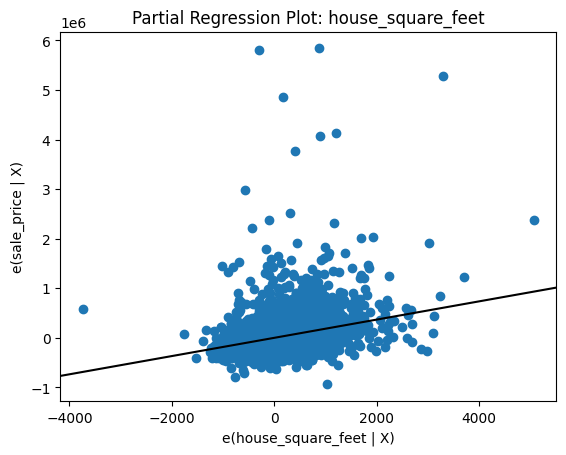

<Figure size 600x400 with 0 Axes>

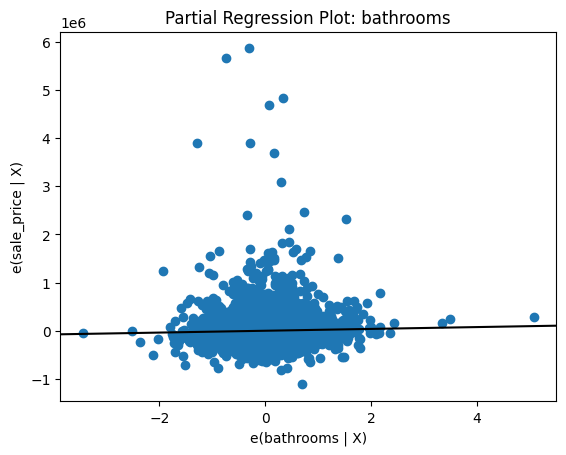

<Figure size 600x400 with 0 Axes>

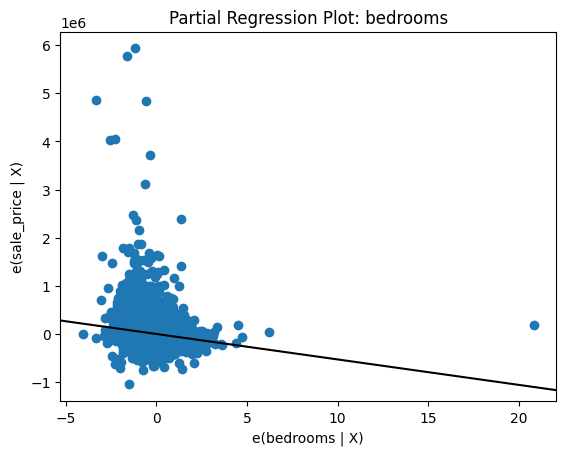

<Figure size 600x400 with 0 Axes>

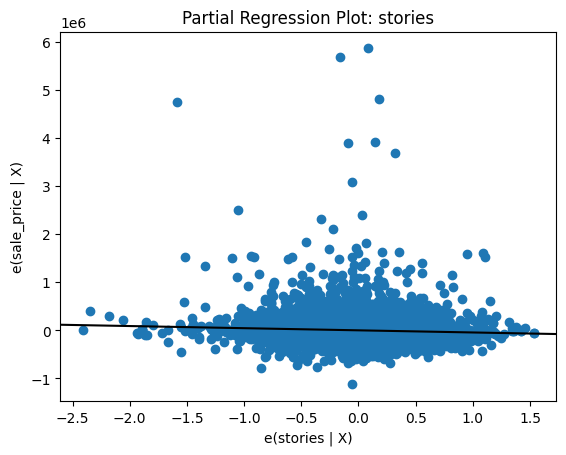

<Figure size 600x400 with 0 Axes>

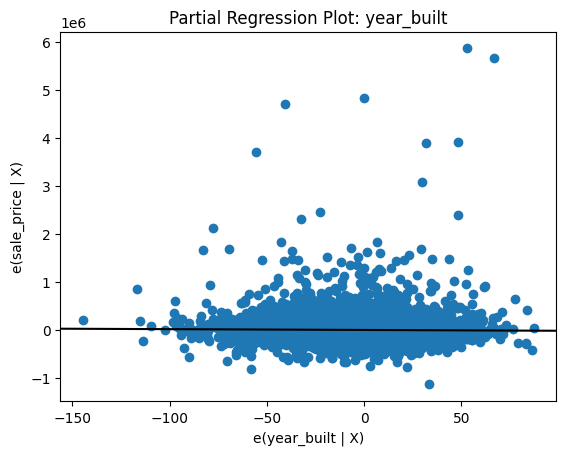

<Figure size 600x400 with 0 Axes>

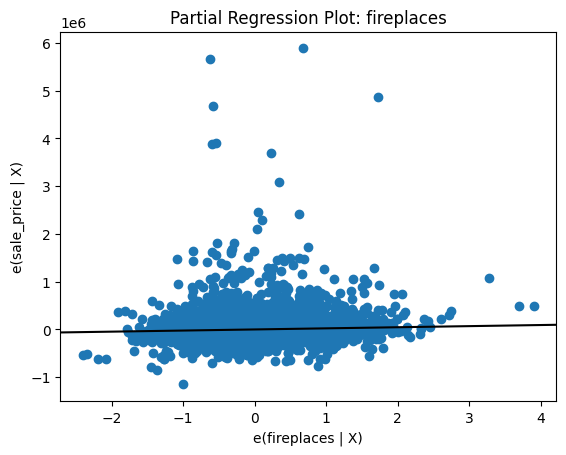

<Figure size 600x400 with 0 Axes>

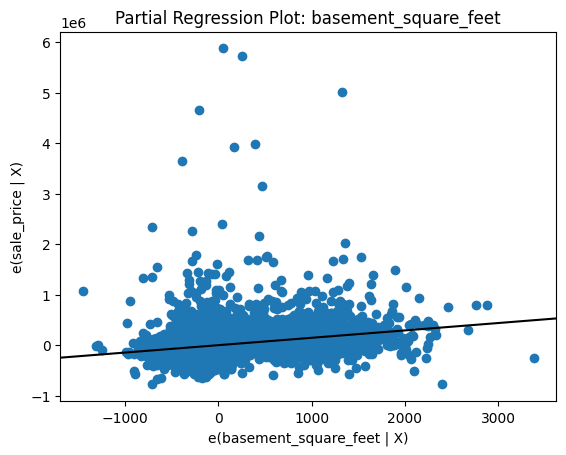

<Figure size 600x400 with 0 Axes>

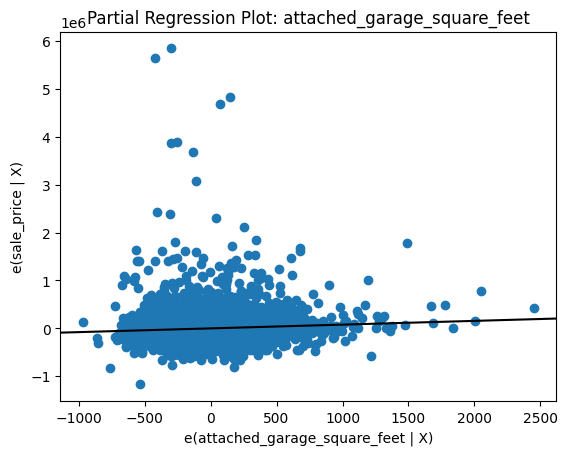

<Figure size 600x400 with 0 Axes>

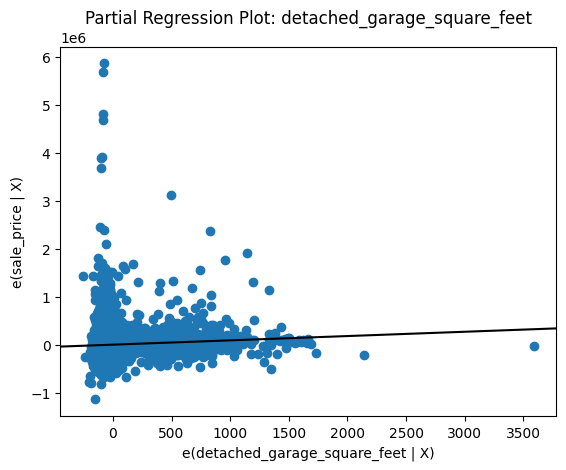

<Figure size 600x400 with 0 Axes>

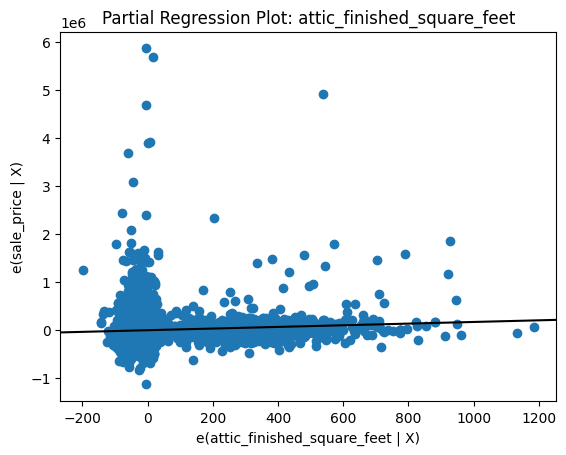

In [6]:
import matplotlib.pyplot as plt
from statsmodels.graphics.regressionplots import plot_partregress

numeric_vars = [
    "house_square_feet",
    "bathrooms",
    "bedrooms",
    "stories",
    "year_built",
    "fireplaces",
    "basement_square_feet",
    "attached_garage_square_feet",
    "detached_garage_square_feet",
    "attic_finished_square_feet"
]

df_partial = df_encoded.copy()

for var in numeric_vars:
    plt.figure(figsize=(6,4))
    plot_partregress(
        endog="sale_price",
        exog_i=var,
        exog_others=[v for v in numeric_vars if v != var],
        data=df_partial,
        obs_labels=False
    )
    plt.title(f"Partial Regression Plot: {var}")
    plt.show()

No major significant non-linearities stand out in these partial regression plots, although house_square_feet shows some mild curvature and possible diminishing returns, and bathrooms looks somewhat step-like because it takes only a few discrete values. Most of the other numeric variables look roughly linear or just noisy with a few influential outliers, so any non-linearity appears modest rather than dramatic.

In [7]:
df_complex = df_clean.copy()

df_complex["sale_month"] = df_complex["sale_date"].dt.month.astype("category")
df_complex["home_age"] = df_complex["sale_date"].dt.year - df_complex["year_built"]

for col in [
    "house_square_feet",
    "basement_square_feet",
    "attached_garage_square_feet",
    "detached_garage_square_feet",
    "attic_finished_square_feet"
]:
    df_complex[f"log1p_{col}"] = np.log1p(df_complex[col].clip(lower=0))

df_complex["house_sqft_x_bathrooms"] = df_complex["house_square_feet"] * df_complex["bathrooms"]
df_complex["house_sqft_x_stories"] = df_complex["house_square_feet"] * df_complex["stories"]
df_complex["house_sqft_x_fireplaces"] = df_complex["house_square_feet"] * df_complex["fireplaces"]
df_complex["bathrooms_sq"] = df_complex["bathrooms"] ** 2
df_complex["bedrooms_sq"] = df_complex["bedrooms"] ** 2
df_complex["age_sq"] = df_complex["home_age"] ** 2
df_complex["bath_per_bed"] = df_complex["bathrooms"] / df_complex["bedrooms"].replace(0, np.nan)
df_complex["garage_total_square_feet"] = df_complex["attached_garage_square_feet"] + df_complex["detached_garage_square_feet"]
df_complex["log1p_garage_total_square_feet"] = np.log1p(df_complex["garage_total_square_feet"].clip(lower=0))
df_complex["basement_share"] = df_complex["basement_square_feet"] / df_complex["house_square_feet"].replace(0, np.nan)
df_complex["attic_share"] = df_complex["attic_finished_square_feet"] / df_complex["house_square_feet"].replace(0, np.nan)
df_complex["garage_share"] = df_complex["garage_total_square_feet"] / df_complex["house_square_feet"].replace(0, np.nan)

for col in ["bath_per_bed", "basement_share", "attic_share", "garage_share"]:
    df_complex[col] = df_complex[col].fillna(0)

categorical_cols = [
    "hvac_description",
    "exterior",
    "interior",
    "roof_cover",
    "waterfront_type",
    "view_quality",
    "utility_sewer",
    "sale_month"
]

numeric_complex = [
    "log1p_house_square_feet",
    "bathrooms",
    "bedrooms",
    "stories",
    "home_age",
    "fireplaces",
    "log1p_basement_square_feet",
    "log1p_attached_garage_square_feet",
    "log1p_detached_garage_square_feet",
    "log1p_attic_finished_square_feet",
    "house_sqft_x_bathrooms",
    "house_sqft_x_stories",
    "house_sqft_x_fireplaces",
    "bathrooms_sq",
    "bedrooms_sq",
    "age_sq",
    "bath_per_bed",
    "log1p_garage_total_square_feet",
    "basement_share",
    "attic_share",
    "garage_share"
]

df_complex_model = df_complex[numeric_complex + categorical_cols + ["sale_price"]].copy()
df_complex_encoded = pd.get_dummies(df_complex_model, columns=categorical_cols, drop_first=True, dtype=int)

X_complex = df_complex_encoded.drop(columns=["sale_price"])
y_complex = np.log1p(df_complex_encoded["sale_price"])

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_complex, y_complex, test_size=0.2, random_state=42
)

complex_model = LinearRegression()
complex_model.fit(Xc_train, yc_train)

yc_train_pred = complex_model.predict(Xc_train)
yc_test_pred = complex_model.predict(Xc_test)

y_train_actual = np.expm1(yc_train)
y_test_actual = np.expm1(yc_test)
y_train_pred = np.expm1(yc_train_pred)
y_test_pred = np.expm1(yc_test_pred)

complex_results = pd.DataFrame([{
    "model": "M6_complex_transformed_interactions",
    "n_features": X_complex.shape[1],
    "train_RMSE": np.sqrt(mean_squared_error(y_train_actual, y_train_pred)),
    "test_RMSE": np.sqrt(mean_squared_error(y_test_actual, y_test_pred)),
    "train_R2": r2_score(y_train_actual, y_train_pred),
    "test_R2": r2_score(y_test_actual, y_test_pred)
}])

complex_results["train_RMSE"] = complex_results["train_RMSE"].round(2)
complex_results["test_RMSE"] = complex_results["test_RMSE"].round(2)
complex_results["train_R2"] = complex_results["train_R2"].round(4)
complex_results["test_R2"] = complex_results["test_R2"].round(4)

display(complex_results)

comparison = pd.concat([results, complex_results], ignore_index=True)
comparison = comparison.sort_values("test_RMSE").reset_index(drop=True)

display(comparison)

,model,n_features,train_RMSE,test_RMSE,train_R2,test_R2
0,M6_complex_transformed_interactions,80,158674.47,152428.36,0.561,0.5286


,model,n_features,train_RMSE,test_RMSE,train_R2,test_R2
0,M6_complex_transformed_interactions,80,158674.47,152428.36,0.5610,0.5286
1,M5_all_simple_predictors,70,158486.97,153156.12,0.5621,0.5241
2,M4_numeric_plus_view_water,22,167484.39,153866.68,0.5110,0.5197
3,M3_extended_numeric,10,185345.20,170421.99,0.4011,0.4108
4,M2_core_numeric,5,196474.03,181278.92,0.3270,0.3333
5,M1_size_only,1,203540.17,189646.86,0.2777,0.2704


The more complex model with transformations and interactions (M6_complex_transformed_interactions) performs slightly better than the simpler models, achieving the lowest test RMSE (152,428.36) and highest test R² (0.5286). This indicates that incorporating transformations and interactions improves predictive performance, but only marginally compared to the full simple model, suggesting diminishing returns from added complexity.

The analysis shows that housing price is primarily driven by size-related features like house_square_feet and bathrooms, along with important categorical factors such as view_quality, and that using all available predictors significantly improves model performance compared to simpler models. While the more complex model with transformations and interactions performs slightly better, the improvement is modest, indicating that the simpler full model already captures most of the signal and that adding complexity yields diminishing returns without clear overfitting, highlighting the importance of balancing model complexity and generalization in model selection